In [13]:
from __future__ import annotations

from pathlib import Path
import re
import pandas as pd
from tqdm import tqdm
import xml.etree.ElementTree as ET

# ============================================================
# CONFIG
# ============================================================
IN_PARQUET  = Path(r"metaspace_images_dump\molformer_pubchem_index.parquet")
OUT_PARQUET = Path(r"metaspace_images_dump\molformer_pubchem_index_enriched_semantic.parquet")

KB_ROOT = Path(r"Y:\coskun-lab\Efe\MSI Foundation Model\knowledge_bases")

CHEBI_DIR    = KB_ROOT / "ChEBI"
PATHBANK_DIR = KB_ROOT / "PathBank"
HMDB_DIR     = KB_ROOT / "HMDB"

CHEBI_STRUCTURES = CHEBI_DIR / "structures.tsv"
CHEBI_COMPOUNDS  = CHEBI_DIR / "compounds.tsv"
CHEBI_NAMES      = CHEBI_DIR / "names.tsv"

PATHBANK_METS     = PATHBANK_DIR / "pathbank_all_metabolites.csv"
PATHBANK_PATHWAYS = PATHBANK_DIR / "pathbank_pathways.csv"   # optional but recommended

HMDB_XML          = HMDB_DIR / "hmdb_metabolites.xml"

# Text limits
MAX_CHEBI_DEF = 600
MAX_HMDB_DESC = 800
MAX_HMDB_TAX  = 600
MAX_PB_DESC   = 600

MAX_SYNONYMS  = 20
TOPK_PATHWAYS = 8

INCHIKEY_RE = re.compile(r"InChIKey=([A-Z]{14}-[A-Z]{10}-[A-Z])")

# ============================================================
# Helpers
# ============================================================
def _clean(x) -> str:
    if x is None:
        return ""
    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass
    return str(x).strip()

def _truncate(s: str, n: int) -> str:
    s = _clean(s)
    if len(s) <= n:
        return s
    return s[: max(0, n - 12)] + " ...[TRUNC]"

def _split_synonyms(s: str):
    s = _clean(s)
    if not s:
        return []
    parts = re.split(r"\s*;\s*|\s*,\s*", s)
    out, seen = [], set()
    for p in parts:
        p = p.strip()
        if not p:
            continue
        pl = p.lower()
        if pl in seen:
            continue
        seen.add(pl)
        out.append(p)
        if len(out) >= MAX_SYNONYMS:
            break
    return out

def _join_list(xs):
    xs = xs or []
    xs = [str(x).strip() for x in xs if str(x).strip()]
    return " ; ".join(xs)

def _file_exists(p: Path) -> bool:
    try:
        return p.exists()
    except Exception:
        return False

def compute_inchikey_series(inchi_s: pd.Series) -> pd.Series:
    """
    1) If InChI contains 'InChIKey=...' extract it fast
    2) Else compute with RDKit from InChI
    """
    s = inchi_s.fillna("").astype(str)

    extracted = s.str.extract(INCHIKEY_RE, expand=False)
    out = extracted.copy()

    need = out.isna() & (s.str.strip().str.len() > 0)
    if need.any():
        try:
            from rdkit.Chem import inchi as rdInchi
        except Exception as e:
            raise RuntimeError(
                "RDKit is required to compute InChIKey from InChI when not embedded. "
                "Install RDKit or ensure InChI strings contain InChIKey=..."
            ) from e

        vals = s[need].tolist()
        keys = []
        for v in tqdm(vals, desc="RDKit InChI->InChIKey", total=len(vals)):
            try:
                mol = rdInchi.MolFromInchi(v, sanitize=True, removeHs=True)
                keys.append(rdInchi.MolToInchiKey(mol) if mol is not None else "")
            except Exception:
                keys.append("")
        out.loc[need] = keys

    out = out.fillna("").astype(str).str.upper()
    out = out.replace("", pd.NA)
    return out

def _strip_ns(tag: str) -> str:
    return tag.split("}", 1)[-1] if "}" in tag else tag

def _text(elem) -> str:
    if elem is None:
        return ""
    return (elem.text or "").strip()

# ============================================================
# ChEBI: best structure per InChIKey
# ============================================================
def chebi_best_structure_per_inchikey(struct: pd.DataFrame) -> pd.DataFrame:
    s = struct[["compound_id", "standard_inchi_key", "standard_inchi", "status_id", "default_structure"]].copy()

    s["compound_id"] = s["compound_id"].fillna("").astype(str).str.strip()
    s["standard_inchi_key"] = s["standard_inchi_key"].fillna("").astype(str).str.strip().str.upper()
    s["standard_inchi"] = s["standard_inchi"].fillna("").astype(str).str.strip()
    s["status_id"] = s["status_id"].fillna("").astype(str).str.strip()
    s["default_structure"] = s["default_structure"].fillna("").astype(str).str.strip().str.lower()

    s = s[s["standard_inchi_key"] != ""]

    s["_is_default"] = (s["default_structure"] == "true").astype(int)
    status_rank = {"1": 3, "3": 2, "2": 1}
    s["_status_rank"] = s["status_id"].map(status_rank).fillna(0).astype(int)

    s = s.sort_values(["standard_inchi_key", "_is_default", "_status_rank"], ascending=[True, False, False])
    s = s.drop_duplicates("standard_inchi_key", keep="first")
    return s.drop(columns=["_is_default", "_status_rank"])

# ============================================================
# HMDB: streaming map by InChIKey (restricted universe)
# ============================================================
def load_hmdb_by_inchikey(hmdb_xml: Path, inchikey_universe: set[str]) -> dict[str, dict]:
    hmdb_by_ik: dict[str, dict] = {}

    if not _file_exists(hmdb_xml):
        print("[WARN] HMDB XML missing; skipping HMDB enrichment.")
        return hmdb_by_ik

    print("[INFO] HMDB: streaming XML and indexing by InChIKey (restricted to universe)...")

    ctx = ET.iterparse(str(hmdb_xml), events=("end",))
    for _, elem in tqdm(ctx, desc="HMDB metabolites"):
        if _strip_ns(elem.tag) != "metabolite":
            continue

        hmdb_id = ""
        name = ""
        desc = ""
        inchikey = ""
        taxonomy_str = ""

        for child in list(elem):
            tag = _strip_ns(child.tag)

            if tag in ("accession", "hmdb_id") and not hmdb_id:
                hmdb_id = _text(child)
            elif tag == "name" and not name:
                name = _text(child)
            elif tag in ("description", "desc") and not desc:
                desc = _text(child)
            elif tag.lower() in ("inchikey", "inchi_key", "inchi-key", "inchikey", "inchikey"):
                if not inchikey:
                    inchikey = _text(child).upper()
            elif tag == "taxonomy" and not taxonomy_str:
                bits = []
                for tchild in list(child):
                    ttag = _strip_ns(tchild.tag)
                    ttext = _text(tchild)
                    if ttext and ttag in ("description", "direct_parent", "kingdom", "class", "sub_class", "super_class"):
                        bits.append(f"{ttag}:{ttext}")
                taxonomy_str = "; ".join(bits)

            # Sometimes inchikey can appear nested under identifiers; be defensive
            if not inchikey and "identifier" in tag.lower():
                for sub in child.iter():
                    stag = _strip_ns(sub.tag).lower()
                    if "inchikey" in stag:
                        val = _text(sub).upper()
                        if val:
                            inchikey = val
                            break

        if inchikey and inchikey in inchikey_universe and inchikey not in hmdb_by_ik:
            hmdb_by_ik[inchikey] = {
                "hmdb_id": hmdb_id,
                "hmdb_name": name,
                "hmdb_description": _truncate(desc, MAX_HMDB_DESC),
                "hmdb_taxonomy": _truncate(taxonomy_str, MAX_HMDB_TAX),
            }

        elem.clear()

    return hmdb_by_ik

# ============================================================
# Build text_semantic (same “style” as before)
# ============================================================
def build_text_semantic(row) -> str:
    name = _clean(row.get("name")) or "(unknown)"

    chebi_def = _truncate(row.get("chebi_definition"), MAX_CHEBI_DEF)
    hmdb_desc = _truncate(row.get("hmdb_description"), MAX_HMDB_DESC)

    # Parse HMDB taxonomy → keep only high-level semantics
    tax = _clean(row.get("hmdb_taxonomy"))
    super_class = class_ = sub_class = ""
    if tax:
        def _grab(k):
            m = re.search(rf"(?:^|;)\s*{re.escape(k)}\s*:\s*([^;]+)", tax)
            return _clean(m.group(1)) if m else ""
        super_class = _grab("super_class")
        class_      = _grab("class")
        sub_class   = _grab("sub_class")

    pb_names = _clean(row.get("pathbank_pathway_names"))

    parts = [f"{name} is a compound"]
    if sub_class:
        parts.append(f"in the {sub_class} subclass")
    if class_:
        parts.append(f"of the {class_} class")
    if super_class:
        parts.append(f"within {super_class}")

    sentence1 = " ".join(parts) + "."

    sentence2 = ""
    if chebi_def:
        sentence2 = chebi_def.rstrip(".") + "."

    sentence3 = ""
    if hmdb_desc:
        sentence3 = hmdb_desc.rstrip(".") + "."

    sentence4 = ""
    if pb_names:
        sentence4 = f"It participates in {pb_names}."

    return " ".join(s for s in [sentence1, sentence2, sentence3, sentence4] if s)

# ============================================================
# MAIN
# ============================================================
def main():
    if not _file_exists(IN_PARQUET):
        raise FileNotFoundError(IN_PARQUET)

    df = pd.read_parquet(IN_PARQUET)
    need_cols = ["name", "cid", "smiles", "inchi"]
    miss = [c for c in need_cols if c not in df.columns]
    if miss:
        raise RuntimeError(f"Input parquet missing required columns: {miss}")

    # Compute inchikey from inchi
    print("[INFO] Computing inchikey from 'inchi' ...")
    df["inchikey"] = compute_inchikey_series(df["inchi"]).astype("object")

    # Ensure normalized helpers
    df["inchi_norm"] = df["inchi"].fillna("").astype(str).str.strip()
    df["inchikey_norm"] = df["inchikey"].fillna("").astype(str).str.strip().str.upper()
    df.loc[df["inchikey_norm"] == "", "inchikey_norm"] = pd.NA

    # ---------------------
    # ChEBI enrichment
    # ---------------------
    if _file_exists(CHEBI_STRUCTURES) and _file_exists(CHEBI_COMPOUNDS) and _file_exists(CHEBI_NAMES):
        print("[INFO] Loading ChEBI TSVs ...")
        chebi_struct = pd.read_csv(CHEBI_STRUCTURES, sep="\t", dtype=str, low_memory=False)
        chebi_comp   = pd.read_csv(CHEBI_COMPOUNDS,  sep="\t", dtype=str, low_memory=False)
        chebi_names  = pd.read_csv(CHEBI_NAMES,      sep="\t", dtype=str, low_memory=False)

        best = chebi_best_structure_per_inchikey(chebi_struct)

        # join best structure via InChIKey
        df = df.merge(
            best[["standard_inchi_key", "compound_id", "standard_inchi"]],
            left_on="inchikey_norm",
            right_on="standard_inchi_key",
            how="left",
        )
        df.drop(columns=["standard_inchi_key"], inplace=True, errors="ignore")

        # fallback via InChI string if compound_id missing
        miss_comp = df["compound_id"].isna() | (df["compound_id"].astype(str).str.strip() == "")
        if miss_comp.any():
            best_inchi = best[best["standard_inchi"].fillna("").astype(str).str.strip() != ""].drop_duplicates("standard_inchi")
            add = df.loc[miss_comp, ["inchi_norm"]].merge(
                best_inchi[["standard_inchi", "compound_id"]],
                left_on="inchi_norm",
                right_on="standard_inchi",
                how="left",
            )
            df.loc[miss_comp, "compound_id"] = add["compound_id"].values

        df["compound_id"] = df["compound_id"].fillna("").astype(str).str.strip()
        df.loc[df["compound_id"] == "", "compound_id"] = pd.NA

        # compounds metadata -> chebi_accession + chebi_definition + chebi_name (optional)
        cc = chebi_comp[["id", "chebi_accession", "name", "definition"]].copy()
        cc["id"] = cc["id"].fillna("").astype(str).str.strip()
        cc = cc.drop_duplicates("id")

        # IMPORTANT: avoid clobbering df["name"]
        cc = cc.rename(columns={
            "name": "chebi_name",
            "definition": "chebi_definition",
        })

        df = df.merge(cc, left_on="compound_id", right_on="id", how="left")
        df.drop(columns=["id"], inplace=True, errors="ignore")


        # synonyms aggregation
        nn = chebi_names[["compound_id", "name"]].copy()
        nn["compound_id"] = nn["compound_id"].fillna("").astype(str).str.strip()
        nn["name"] = nn["name"].fillna("").astype(str).str.strip()
        nn = nn[(nn["compound_id"] != "") & (nn["name"] != "")]

        print("[INFO] ChEBI: aggregating synonyms ...")
        syn_map = {}
        for cid2, g in tqdm(
            nn.groupby("compound_id"),
            total=nn["compound_id"].nunique(),
            desc="ChEBI synonym groups",
        ):
            seen = []
            for v in g["name"].tolist():
                if v not in seen:
                    seen.append(v)
                if len(seen) >= MAX_SYNONYMS:
                    break
            syn_map[cid2] = seen

        df["chebi_synonyms_list"] = df["compound_id"].map(syn_map)
        df["chebi_synonyms_list"] = df["chebi_synonyms_list"].apply(lambda x: x if isinstance(x, list) else [])
        df["chebi_synonyms_topk"] = df["chebi_synonyms_list"].apply(lambda xs: _join_list(xs[:MAX_SYNONYMS]))

        # Keep only required chebi columns (if you want to drop helpers later)
        df["chebi_accession"] = df["chebi_accession"].fillna("").astype(str).str.strip()
        df.loc[df["chebi_accession"] == "", "chebi_accession"] = pd.NA
        df["chebi_definition"] = df["chebi_definition"].fillna("").astype(str).str.strip()
        df.loc[df["chebi_definition"] == "", "chebi_definition"] = pd.NA
    else:
        print("[WARN] ChEBI files missing; skipping ChEBI enrichment.")
        df["chebi_accession"] = pd.NA
        df["chebi_definition"] = pd.NA
        df["chebi_synonyms_list"] = [[] for _ in range(len(df))]
        df["chebi_synonyms_topk"] = ""

    # ---------------------
    # HMDB enrichment
    # ---------------------
    ik_universe = set(df["inchikey_norm"].dropna().astype(str).str.upper().tolist())
    ik_universe.discard("")
    hmdb_map = load_hmdb_by_inchikey(HMDB_XML, ik_universe) if _file_exists(HMDB_XML) else {}

    if hmdb_map:
        print("[INFO] HMDB: applying joins ...")
        df["hmdb_id"] = df["inchikey_norm"].map(lambda k: hmdb_map.get(k, {}).get("hmdb_id", ""))
        df["hmdb_description"] = df["inchikey_norm"].map(lambda k: hmdb_map.get(k, {}).get("hmdb_description", ""))
        df["hmdb_taxonomy"] = df["inchikey_norm"].map(lambda k: hmdb_map.get(k, {}).get("hmdb_taxonomy", ""))
        for c in ["hmdb_id", "hmdb_description", "hmdb_taxonomy"]:
            df[c] = df[c].fillna("").astype(str).str.strip()
            df.loc[df[c] == "", c] = pd.NA
    else:
        print("[WARN] HMDB map empty; skipping HMDB joins.")
        df["hmdb_id"] = pd.NA
        df["hmdb_description"] = pd.NA
        df["hmdb_taxonomy"] = pd.NA

    # ---------------------
    # PathBank enrichment
    # ---------------------
    if _file_exists(PATHBANK_METS):
        print("[INFO] PathBank: loading metabolites CSV ...")
        pb_usecols = ["PathBank ID", "Pathway Name", "Metabolite ID", "Metabolite Name", "InChI", "InChI Key"]
        pb = pd.read_csv(PATHBANK_METS, dtype=str, low_memory=False, usecols=pb_usecols)

        pb["InChI Key"] = pb["InChI Key"].fillna("").astype(str).str.strip().str.upper()
        pb["InChI"] = pb["InChI"].fillna("").astype(str).str.strip()
        pb["PathBank ID"] = pb["PathBank ID"].fillna("").astype(str).str.strip()
        pb["Pathway Name"] = pb["Pathway Name"].fillna("").astype(str).str.strip()

        # join by inchikey
        pb_key = pb[pb["InChI Key"] != ""].drop_duplicates("InChI Key")
        df = df.merge(
            pb_key[["InChI Key", "PathBank ID"]],
            left_on="inchikey_norm",
            right_on="InChI Key",
            how="left",
        )
        df.rename(columns={"PathBank ID": "pathbank_smpdb_id"}, inplace=True)
        df.drop(columns=["InChI Key"], inplace=True, errors="ignore")

        # fallback join by InChI if missing
        miss_pb = df["pathbank_smpdb_id"].isna() | (df["pathbank_smpdb_id"].astype(str).str.strip() == "")
        if miss_pb.any():
            pb_inchi = pb[pb["InChI"] != ""].drop_duplicates("InChI")
            add = df.loc[miss_pb, ["inchi_norm"]].merge(
                pb_inchi[["InChI", "PathBank ID"]],
                left_on="inchi_norm",
                right_on="InChI",
                how="left",
            )
            df.loc[miss_pb, "pathbank_smpdb_id"] = add["PathBank ID"].values

        # pathway names per SMPDB/PathBank ID
        print("[INFO] PathBank: aggregating pathway names ...")
        pb2 = pb[(pb["PathBank ID"] != "") & (pb["Pathway Name"] != "")]
        pb_map = {}
        for pid, g in tqdm(
            pb2.groupby("PathBank ID"),
            total=pb2["PathBank ID"].nunique(),
            desc="PathBank pathway-name groups",
        ):
            seen = []
            for v in g["Pathway Name"].tolist():
                if v not in seen:
                    seen.append(v)
                if len(seen) >= TOPK_PATHWAYS:
                    break
            pb_map[pid] = " ; ".join(seen)

        df["pathbank_pathway_names"] = df["pathbank_smpdb_id"].map(pb_map)
        df["pathbank_pathway_names"] = df["pathbank_pathway_names"].fillna("").astype(str).str.strip()
        df.loc[df["pathbank_pathway_names"] == "", "pathbank_pathway_names"] = pd.NA

        # pathway descriptions
        if _file_exists(PATHBANK_PATHWAYS):
            print("[INFO] PathBank: joining pathway descriptions ...")
            pbp = pd.read_csv(PATHBANK_PATHWAYS, dtype=str, low_memory=False)
            pbp["SMPDB ID"] = pbp["SMPDB ID"].fillna("").astype(str).str.strip()
            pbp = pbp.drop_duplicates("SMPDB ID")
            df = df.merge(
                pbp[["SMPDB ID", "Description"]],
                left_on="pathbank_smpdb_id",
                right_on="SMPDB ID",
                how="left",
            )
            df.rename(columns={"Description": "pathbank_pathway_desc"}, inplace=True)
            df.drop(columns=["SMPDB ID"], inplace=True, errors="ignore")
        else:
            df["pathbank_pathway_desc"] = pd.NA

        df["pathbank_pathway_desc"] = df["pathbank_pathway_desc"].fillna("").astype(str).str.strip()
        df.loc[df["pathbank_pathway_desc"] == "", "pathbank_pathway_desc"] = pd.NA

    else:
        print("[WARN] PathBank metabolites CSV missing; skipping PathBank enrichment.")
        df["pathbank_pathway_names"] = pd.NA
        df["pathbank_pathway_desc"] = pd.NA

    # ---------------------
    # text_semantic
    # ---------------------
    print("[INFO] Building text_semantic ...")
    tqdm.pandas(desc="text_semantic")
    df["text_semantic"] = df.progress_apply(build_text_semantic, axis=1)

    # ---------------------
    # Final: keep original columns + requested enrichment columns only
    # ---------------------
    keep_cols = [
        "name", "cid", "smiles", "inchi",
        "inchikey",
        "chebi_accession", "chebi_definition", "chebi_synonyms_list", "chebi_synonyms_topk",
        "hmdb_id", "hmdb_description", "hmdb_taxonomy",
        "pathbank_pathway_names", "pathbank_pathway_desc",
        "text_semantic",
    ]
    for c in keep_cols:
        if c not in df.columns:
            df[c] = pd.NA

    out = df[keep_cols].copy()

    # Save
    OUT_PARQUET.parent.mkdir(parents=True, exist_ok=True)
    out.to_parquet(OUT_PARQUET, index=False)

    # Coverage summary
    def cov(col: str) -> int:
        if col not in out.columns:
            return 0
        if col == "chebi_synonyms_list":
            return int(out[col].apply(lambda x: isinstance(x, list) and len(x) > 0).sum())
        return int(out[col].notna().sum())

    print("[DONE] wrote:", OUT_PARQUET)
    print("\nCoverage:")
    print("  inchikey:", cov("inchikey"))
    print("  chebi_accession:", cov("chebi_accession"))
    print("  chebi_definition:", cov("chebi_definition"))
    print("  chebi_synonyms_list(non-empty):", cov("chebi_synonyms_list"))
    print("  hmdb_id:", cov("hmdb_id"))
    print("  pathbank_pathway_names:", cov("pathbank_pathway_names"))

if __name__ == "__main__":
    main()


[INFO] Computing inchikey from 'inchi' ...


RDKit InChI->InChIKey:  33%|███▎      | 9977/30478 [00:07<00:20, 991.24it/s] [22:33:48] WARNING:  Problems/mismatches: Mobile-H( Hydrogens: Number; Mobile-H groups: Number; Charge(s): Do not match)

RDKit InChI->InChIKey: 100%|██████████| 30478/30478 [00:21<00:00, 1446.97it/s]


[INFO] Loading ChEBI TSVs ...
[INFO] ChEBI: aggregating synonyms ...


ChEBI synonym groups: 100%|██████████| 154338/154338 [00:03<00:00, 41832.68it/s]


[INFO] HMDB: streaming XML and indexing by InChIKey (restricted to universe)...


...

[INFO] HMDB: applying joins ...
[INFO] PathBank: loading metabolites CSV ...
[INFO] PathBank: aggregating pathway names ...


PathBank pathway-name groups: 100%|██████████| 110158/110158 [00:02<00:00, 39527.63it/s]


[INFO] PathBank: joining pathway descriptions ...
[INFO] Building text_semantic ...


text_semantic: 100%|██████████| 30478/30478 [00:01<00:00, 29191.59it/s]


[DONE] wrote: metaspace_images_dump\molformer_pubchem_index_enriched_semantic.parquet

Coverage:
  inchikey: 30478
  chebi_accession: 15380
  chebi_definition: 4390
  chebi_synonyms_list(non-empty): 15102
  hmdb_id: 25494
  pathbank_pathway_names: 12629


In [1]:
import pandas as pd
df = pd.read_parquet(r"metaspace_images_dump\molformer_pubchem_index_enriched_semantic.parquet")
df

,name,cid,smiles,inchi,inchikey,chebi_accession,chebi_definition,chebi_synonyms_list,chebi_synonyms_topk,hmdb_id,hmdb_description,hmdb_taxonomy,pathbank_pathway_names,pathbank_pathway_desc,text_semantic
0,(+)-(S)-Carvone,CID16724,CC1=CC[C@@H](CC1=O)C(=C)C,InChI=1S/C10H14O/c1-7(2)9-5-4-8(3)10(11)6-9/h4...,ULDHMXUKGWMISQ-VIFPVBQESA-N,CHEBI:15399,A carvone having (<i>S</i>) configuration.,"[(+)-(4<i>S</i>)-carvone, (5<i>S</i>)-2-methyl...",(+)-(4<i>S</i>)-carvone ; (5<i>S</i>)-2-methyl...,HMDB0004487,"Carvone, with R and S isomers, also known as c...",description:belongs to the class of organic co...,None,None,(+)-(S)-Carvone is a compound in the Monoterpe...
1,"(+)-1(10),4-Cadinadiene",CID441005,CC1=C[C@H]2[C@@H](CCC(=C2CC1)C)C(C)C,InChI=1S/C15H24/c1-10(2)13-8-6-12(4)14-7-5-11(...,FUCYIEXQVQJBKY-ZFWWWQNUSA-N,CHEBI:15385,A member of the cadinene family of sesquiterpe...,"[δ-amorphene, (+)-delta-Cadinene, (1<i>S</i>,8...","δ-amorphene ; (+)-delta-Cadinene ; (1<i>S</i>,...",HMDB0035084,"(+)-1(10),4-Cadinadiene is found in allspice. ...",description:belongs to the class of organic co...,None,None,"(+)-1(10),4-Cadinadiene is a compound in the S..."
2,"(+)-1(9),10-Pacifigorgiadiene",CID131752220,CC1CCC2C(CC=C2C1C=C(C)C)C,InChI=1S/C15H24/c1-10(2)9-15-12(4)5-7-13-11(3)...,DMSFMSTWAVYMQU-UHFFFAOYSA-N,None,None,[],,HMDB0037677,"(+)-1(9),10-Pacifigorgiadiene is found in fats...",description:belongs to the class of organic co...,None,None,"(+)-1(9),10-Pacifigorgiadiene is a compound in..."
3,"(+)-1,18-Nonacosanediol",CID86172616,CCCCCCCCCCCC(CCCCCCCCCCCCCCCCCO)O,InChI=1S/C29H60O2/c1-2-3-4-5-6-14-17-20-23-26-...,BCSKSPASEHRYJF-UHFFFAOYSA-N,None,None,[],,HMDB0041004,"(+)-1,18-Nonacosanediol is a constituent of Pa...",description:belongs to the class of organic co...,None,None,"(+)-1,18-Nonacosanediol is a compound in the F..."
4,(+)-1-Methylpropyl 3-(methylthio)-2-propenyl d...,CID88158913,CCC(C)SSC/C=C/SC,InChI=1S/C8H16S3/c1-4-8(2)11-10-7-5-6-9-3/h5-6...,JNQZEVXCRPIXDB-AATRIKPKSA-N,CHEBI:174032,None,[2-[[(E)-3-methylsulanylprop-2-enyl]disulanyl]...,2-[[(E)-3-methylsulanylprop-2-enyl]disulanyl]b...,HMDB0034425,(+)-1-Methylpropyl 3-(methylthio)-2-propenyl d...,description:belongs to the class of organic co...,None,None,(+)-1-Methylpropyl 3-(methylthio)-2-propenyl d...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30473,{[4-(7-methoxy-2-oxo-2H-chromen-6-yl)butan-2-y...,CID131835273,CC(CCC1=C(C=C2C(=C1)C=CC(=O)O2)OC)OS(=O)(=O)O,"InChI=1S/C14H16O7S/c1-9(21-22(16,17)18)3-4-10-...",FPKYLMTUFQHSLV-UHFFFAOYSA-N,CHEBI:186252,None,[4-(7-methoxy-2-oxochromen-6-yl)butan-2-yl hyd...,4-(7-methoxy-2-oxochromen-6-yl)butan-2-yl hydr...,None,None,None,None,None,{[4-(7-methoxy-2-oxo-2H-chromen-6-yl)butan-2-y...
30474,{[5-(4-methoxyphenyl)-2-methyl-3-oxopent-4-en-...,CID131836946,CC(COS(=O)(=O)O)C(=O)/C=C/C1=CC=C(C=C1)OC,"InChI=1S/C13H16O6S/c1-10(9-19-20(15,16)17)13(1...",NKFVIZXJXWXONC-VMPITWQZSA-N,CHEBI:168821,None,[[(E)-5-(4-methoxyphenyl)-2-methyl-3-oxopent-4...,[(E)-5-(4-methoxyphenyl)-2-methyl-3-oxopent-4-...,None,None,None,None,None,{[5-(4-methoxyphenyl)-2-methyl-3-oxopent-4-en-...
30475,{[5-(4-methoxyphenyl)-3-oxopentan-2-yl]oxy}sul...,CID131836979,CC(C(=O)CCC1=CC=C(C=C1)OC)OS(=O)(=O)O,"InChI=1S/C12H16O6S/c1-9(18-19(14,15)16)12(13)8...",JLWTWYKAYOHXEM-UHFFFAOYSA-N,CHEBI:229926,None,[[5-(4-methoxyphenyl)-3-oxopentan-2-yl] hydrog...,[5-(4-methoxyphenyl)-3-oxopentan-2-yl] hydroge...,None,None,None,None,None,{[5-(4-methoxyphenyl)-3-oxopentan-2-yl]oxy}sul...
30476,{[5-(4-methoxyphenyl)-3-oxopentyl]oxy}sulfonic...,CID131836983,COC1=CC=C(C=C1)CCC(=O)CCOS(=O)(=O)O,InChI=1S/C12H16O6S/c1-17-12-6-3-10(4-7-12)2-5-...,SZRKNRKPOZEPFL-UHFFFAOYSA-N,CHEBI:169830,None,[[5-(4-methoxyphenyl)-3-oxopentyl] hydrogen su...,[5-(4-methoxyphenyl)-3-oxopentyl] hydrogen sulate,None,None,None,None,None,{[5-(4-methoxyphenyl)-3-oxopentyl]oxy}sulfonic...


In [2]:
# ============================================================
# BioLinkBERT embedding for molecule KB
# ============================================================

import hashlib
import re
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModel

# ============================
# CONFIG
# ============================
IN_PARQUET = Path(r"metaspace_images_dump/molformer_pubchem_index_enriched_semantic.parquet")

TEXT_COL = "text_semantic"
CID_COL  = "cid"

MODEL_NAME = "michiyasunaga/BioLinkBERT-base"    # or "michiyasunaga/BioLinkBERT-large"
MAX_LENGTH = 384
BATCH_SIZE = 64
USE_FP16   = True
L2_NORM    = True

OUT_EMB = Path(r"metaspace_images_dump/cand_molecule_biolinkbert_embeddings.npy")
OUT_IDX = Path(r"metaspace_images_dump/cand_molecule_biolinkbert_index.parquet")

OUT_EMB.parent.mkdir(parents=True, exist_ok=True)

# ============================
# HTML stripper
# ============================
TAG_RE = re.compile(r"<[^>]+>")

def strip_html(s: str) -> str:
    s = "" if s is None else str(s)
    return TAG_RE.sub("", s)

# ============================
# Helpers
# ============================
def mean_pool(last_hidden, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(last_hidden)
    summed = (last_hidden * mask).sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1e-6)
    return summed / denom

def sha1_text(s: str) -> str:
    return hashlib.sha1((s or "").encode("utf-8", errors="ignore")).hexdigest()

# Accepts: 16724, "16724", "CID16724", "cid:16724", "CID 16724"
CID_RE = re.compile(r"(\d+)")

def parse_cid(x):
    """
    Return an integer CID if possible, else None.
    Examples:
      "CID16724" -> 16724
      "16724"    -> 16724
      None/""    -> None
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    s = str(x).strip()
    if not s:
        return None
    m = CID_RE.search(s)
    if not m:
        return None
    try:
        return int(m.group(1))
    except Exception:
        return None

# ============================
# Load KB
# ============================
df = pd.read_parquet(IN_PARQUET)

# Clean text
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str).map(strip_html)
df = df[df[TEXT_COL].str.strip().str.len() > 0].reset_index(drop=True)

# Parse CID into a numeric column (keep original CID_COL as-is)
df["cid_int"] = df[CID_COL].map(parse_cid)

# Drop rows where CID couldn't be parsed (recommended)
bad = df["cid_int"].isna().sum()
if bad:
    print(f"[WARN] Dropping {bad} rows with unparseable CID in '{CID_COL}'.")
    df = df[df["cid_int"].notna()].reset_index(drop=True)

N = len(df)
print("Molecules:", N)

if N == 0:
    raise RuntimeError("No valid rows left after filtering text/CID. Check your parquet columns.")

# ============================
# Device
# ============================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ============================
# Load BioLinkBERT
# ============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

H = model.config.hidden_size
print("Hidden dim:", H)

# ============================
# Allocate outputs (NORMAL in-memory array)
# ============================
embeddings = np.empty((N, H), dtype=np.float32)
index_rows = []

# ============================
# Embed
# ============================
use_amp = (USE_FP16 and device == "cuda")

with torch.no_grad():
    for i in tqdm(range(0, N, BATCH_SIZE), desc="Embedding"):
        j = min(i + BATCH_SIZE, N)
        texts = df.iloc[i:j][TEXT_COL].tolist()

        tok = tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        tok = {k: v.to(device) for k, v in tok.items()}

        if use_amp:
            with torch.cuda.amp.autocast():
                out = model(**tok)
                pooled = mean_pool(out.last_hidden_state, tok["attention_mask"])
        else:
            out = model(**tok)
            pooled = mean_pool(out.last_hidden_state, tok["attention_mask"])

        pooled = pooled.float()

        if L2_NORM:
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)

        embeddings[i:j, :] = pooled.cpu().numpy().astype(np.float32)

        # index rows
        # (row is the filtered df row index; cid keeps both original + parsed)
        for k in range(i, j):
            t = df.at[k, TEXT_COL]
            index_rows.append({
                "row": int(k),
                "cid_raw": str(df.at[k, CID_COL]),
                "cid": int(df.at[k, "cid_int"]),
                "text_len": int(len(t)),
                "text_sha1": sha1_text(t),
            })

# ============================
# Save embeddings (NORMAL .npy)
# ============================
np.save(OUT_EMB, embeddings)

# ============================
# Save index
# ============================
idx = pd.DataFrame(index_rows)
idx.to_parquet(OUT_IDX, index=False)

print("\n[DONE]")
print("Embeddings:", OUT_EMB, f"({N} x {H})")
print("Index     :", OUT_IDX)


Molecules: 30478
Device: cuda
Hidden dim: 768


Embedding:   0%|          | 0/477 [00:00<?, ?it/s]C:\Users\eozturk7\AppData\Local\Temp\ipykernel_22396\1791352842.py:145: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Embedding: 100%|██████████| 477/477 [01:34<00:00,  5.05it/s]



[DONE]
Embeddings: metaspace_images_dump\cand_molecule_biolinkbert_embeddings.npy (30478 x 768)
Index     : metaspace_images_dump\cand_molecule_biolinkbert_index.parquet


In [3]:
import pandas as pd
df = pd.read_parquet(r"metaspace_images_dump\cand_molecule_biolinkbert_index.parquet")
df

,row,cid_raw,cid,text_len,text_sha1
0,0,CID16724,16724,964,810e142422cba813976bac3c6d970dddc8dc02f8
1,1,CID441005,441005,545,9350b503c4afe50a705b20c44e3eaba2c5c164b4
2,2,CID131752220,131752220,282,0c8d989e139b399fdb3fa93292877dcceb381f87
3,3,CID86172616,86172616,211,86679b460fa7b924209cf457c1ac7c70f90fd5c9
4,4,CID88158913,88158913,359,b051c6d150c5d644ba52ae5281f8aee9422a10a2
...,...,...,...,...,...
30473,30473,CID131835273,131835273,80,40862c763821c43879a27ed398ca9540d0dcb1db
30474,30474,CID131836946,131836946,83,57d588dc4463a8c0a727508cf7be772181178531
30475,30475,CID131836979,131836979,71,124cd3051b1a4e2b8a65b967c8bcffd157a0c895
30476,30476,CID131836983,131836983,66,7c2957fd51efe05666d293635dff38b9d2ef069f


In [4]:
# ============================================================
# Validate BioLinkBERT embedding quality (single Jupyter cell)
# Evaluations:
#   1) HMDB taxonomy label extraction → kNN purity + baseline + lift
#   2) PathBank pathway overlap → mean neighbor Jaccard + shuffled baseline
#   3) Pathway retrieval hit-rate@10 (for pathways with enough members)
#   4) Optional: spot-check neighbors for a given CID (set SPOT_CID)
# ============================================================

import re, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

# ----------------------------
# PATHS / CONFIG
# ----------------------------
EMB_NPY = Path(r"metaspace_images_dump/cand_molecule_biolinkbert_embeddings.npy")
IDX_PQ  = Path(r"metaspace_images_dump/cand_molecule_biolinkbert_index.parquet")
KB_PQ   = Path(r"metaspace_images_dump/molformer_pubchem_index_enriched_semantic.parquet")  # <-- use this now

# kNN settings
KNN_K = 11                # includes self, we use neighbors 1..KNN_K-1
MIN_PATHWAY_MEMBERS = 15  # for pathway retrieval eval
SEED = 6740

# Optional spot-check (set None to skip). Can be int (16724) or "CID16724"
SPOT_CID = 19

# ----------------------------
# Helpers
# ----------------------------
CID_RE = re.compile(r"(\d+)")

def parse_cid(x):
    """
    Return integer CID if possible, else None.
    Accepts: 16724, "16724", "CID16724", "cid:16724", "CID 16724"
    """
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return None
    s = str(x).strip()
    if not s:
        return None
    m = CID_RE.search(s)
    if not m:
        return None
    try:
        return int(m.group(1))
    except Exception:
        return None

def extract_tax_field(tax: str, key: str):
    if not isinstance(tax, str) or not tax.strip():
        return None
    m = re.search(rf"(?:^|;\s*){re.escape(key)}:([^;]+)", tax)
    return m.group(1).strip() if m else None

def split_paths(s):
    if not isinstance(s, str) or not s.strip():
        return []
    parts = [p.strip() for p in re.split(r"\s*;\s*", s) if p.strip()]
    return parts

def jaccard(a, b):
    A, B = set(a), set(b)
    if not A and not B:
        return 1.0
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

def topk_neighbors(df_aligned, E, row_idx, k=15):
    # assumes L2-normalized embeddings so dot = cosine
    q = E[row_idx:row_idx+1]
    sims = (E @ q.T).ravel()
    top = np.argsort(-sims)[:k+1]
    top = [i for i in top if i != row_idx][:k]

    cols_pref = [
        "row", "cid_raw", "cid",
        "name", "name_primary",
        "hmdb_id", "chebi_accession",
        "pathbank_pathway_names"
    ]
    cols = [c for c in cols_pref if c in df_aligned.columns]
    out = df_aligned.loc[top, cols].copy()
    out["cosine"] = sims[top]
    return out

# ----------------------------
# Reproducibility
# ----------------------------
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------
# Load embeddings + index + KB
# ----------------------------
if not EMB_NPY.exists():
    raise FileNotFoundError(f"Embeddings not found: {EMB_NPY}")
if not IDX_PQ.exists():
    raise FileNotFoundError(f"Index not found: {IDX_PQ}")
if not KB_PQ.exists():
    raise FileNotFoundError(f"KB parquet not found: {KB_PQ}")

E = np.load(EMB_NPY)  # <-- regular npy load
if E.dtype != np.float32:
    E = E.astype(np.float32, copy=False)

idx = pd.read_parquet(IDX_PQ)
kb  = pd.read_parquet(KB_PQ)

print("[INFO] Loaded embeddings:", E.shape, E.dtype)
print("[INFO] Index rows:", len(idx))
print("[INFO] KB rows:", len(kb))

# Ensure there is a 'row' in KB and align on it
kb = kb.copy()
if "row" not in kb.columns:
    # If you never stored 'row' in KB, assume current order corresponds to embedding order
    # (This is common if you embedded after filtering and reset_index(drop=True))
    kb["row"] = np.arange(len(kb), dtype=int)

# Parse CID in KB (string "CID####" -> int)
if "cid" in kb.columns:
    kb["cid_raw"] = kb["cid"].astype(str)
    kb["cid"] = kb["cid"].map(parse_cid).astype("Int64")
else:
    kb["cid_raw"] = None
    kb["cid"] = pd.Series([pd.NA] * len(kb), dtype="Int64")

# Merge KB + embedding index on "row"
df = (
    kb.merge(idx[["row", "cid_raw", "cid", "text_len", "text_sha1"]], on="row", how="inner", suffixes=("_kb", ""))
    .sort_values("row")
    .reset_index(drop=True)
)

# Prefer idx cid columns (already parsed) if present
if "cid_raw" not in df.columns and "cid_raw_kb" in df.columns:
    df["cid_raw"] = df["cid_raw_kb"]
if "cid" not in df.columns and "cid_kb" in df.columns:
    df["cid"] = df["cid_kb"]

# Final sanity
if len(df) != E.shape[0]:
    raise RuntimeError(f"Row mismatch: aligned df={len(df)} vs E={E.shape[0]}")

print("[INFO] Aligned rows:", len(df), "Emb dim:", E.shape[1])

# ----------------------------
# 1) HMDB taxonomy class kNN purity
# ----------------------------
if "hmdb_taxonomy" in df.columns:
    labels = df["hmdb_taxonomy"].astype(str).map(lambda s: extract_tax_field(s, "class"))
    labels = labels.fillna("UNK").values

    valid = labels != "UNK"
    if valid.sum() >= 100:
        E_valid = E[valid]
        y = labels[valid]

        nn = NearestNeighbors(n_neighbors=KNN_K, metric="cosine").fit(E_valid)
        dist, nbrs = nn.kneighbors(E_valid, return_distance=True)

        purity_per = (y[nbrs[:, 1:]] == y[:, None]).mean(axis=1)
        purity = float(purity_per.mean())

        vals, counts = np.unique(y, return_counts=True)
        p = counts / counts.sum()
        baseline = float((p**2).sum())
        lift = purity / baseline if baseline > 0 else np.nan

        print("\n[HMDB TAXONOMY] (label=class:...)")
        print("  non-UNK coverage:", f"{valid.mean()*100:.1f}%")
        print("  n_classes:", len(vals))
        print(f"  kNN purity@{KNN_K-1}: {purity:.4f}")
        print(f"  random baseline:    {baseline:.4f}")
        print(f"  lift:               {lift:.2f}x")
    else:
        print("\n[HMDB TAXONOMY] Not enough labeled rows (need ~100+).")
else:
    print("\n[HMDB TAXONOMY] Column 'hmdb_taxonomy' not found in KB parquet.")

# ----------------------------
# 2) Pathway overlap validation (neighbor Jaccard) + shuffled baseline
# ----------------------------
if "pathbank_pathway_names" in df.columns:
    df["pb_paths"] = df["pathbank_pathway_names"].astype(str).map(split_paths)
    mask = df["pb_paths"].map(len) > 0

    if mask.sum() >= 100:
        E_pb = E[mask.values]
        paths_list = df.loc[mask, "pb_paths"].tolist()

        nn_pb = NearestNeighbors(n_neighbors=KNN_K, metric="cosine").fit(E_pb)
        dist_pb, nbrs_pb = nn_pb.kneighbors(E_pb, return_distance=True)

        j_scores = []
        for i in range(len(E_pb)):
            nei = nbrs_pb[i, 1:]
            j_scores.append(np.mean([jaccard(paths_list[i], paths_list[j]) for j in nei]))
        mean_j = float(np.mean(j_scores))

        paths_shuf = paths_list.copy()
        random.shuffle(paths_shuf)
        j_scores_shuf = []
        for i in range(len(E_pb)):
            nei = nbrs_pb[i, 1:]
            j_scores_shuf.append(np.mean([jaccard(paths_shuf[i], paths_shuf[j]) for j in nei]))
        mean_j_shuf = float(np.mean(j_scores_shuf))

        print("\n[PATHBANK] Neighbor pathway overlap")
        print("  pathway-labeled coverage:", f"{mask.mean()*100:.1f}%")
        print(f"  mean Jaccard@{KNN_K-1}NN:     {mean_j:.4f}")
        print(f"  shuffled baseline Jaccard: {mean_j_shuf:.4f}")
        if mean_j_shuf > 0:
            print(f"  lift:                     {mean_j/mean_j_shuf:.2f}x")
    else:
        print("\n[PATHBANK] Not enough pathway-labeled rows (need ~100+).")
else:
    print("\n[PATHBANK] Column 'pathbank_pathway_names' not found in KB parquet.")

# ----------------------------
# 3) Pathway retrieval hit-rate@10 (for pathways with enough members)
# ----------------------------
if "pathbank_pathway_names" in df.columns:
    if "pb_paths" not in df.columns:
        df["pb_paths"] = df["pathbank_pathway_names"].astype(str).map(split_paths)

    mask = df["pb_paths"].map(len) > 0
    if mask.sum() >= 100:
        E_pb = E[mask.values]
        paths_list = df.loc[mask, "pb_paths"].tolist()

        nn_pb = NearestNeighbors(n_neighbors=max(KNN_K, 11), metric="cosine").fit(E_pb)
        dist_pb, nbrs_pb = nn_pb.kneighbors(E_pb, return_distance=True)

        pb_map = defaultdict(list)
        for i, paths in enumerate(paths_list):
            for pth in paths:
                pb_map[pth].append(i)

        candidates = [p for p, xs in pb_map.items() if len(xs) >= MIN_PATHWAY_MEMBERS]
        print("\n[PATHBANK] Pathways with >=", MIN_PATHWAY_MEMBERS, "members:", len(candidates))

        hits = []
        for pth in candidates[:300]:  # cap for speed
            xs = pb_map[pth]
            xs_set = set(xs)
            for i in xs:
                nei = nbrs_pb[i, 1:11]  # top-10 neighbors excluding self
                hits.append(any(j in xs_set for j in nei))

        if hits:
            print(f"  hit-rate@10 (same-pathway neighbor exists): {float(np.mean(hits)):.4f}")
        else:
            print("  No hits computed (no pathways met criteria).")

# ----------------------------
# 4) Spot-check neighbors for a CID
# ----------------------------
if SPOT_CID is not None:
    target = parse_cid(SPOT_CID)
    if target is None:
        print(f"\n[SPOT CHECK] Could not parse SPOT_CID={SPOT_CID!r}")
    elif "cid" not in df.columns:
        print("\n[SPOT CHECK] No 'cid' column in df.")
    else:
        cid_series = df["cid"]
        if pd.api.types.is_integer_dtype(cid_series):
            m = (cid_series == target)
        else:
            m = (cid_series.astype("Int64") == target)

        if m.any():
            row_idx = int(df.index[m][0])
            print(f"\n[SPOT CHECK] CID {target} at row {row_idx}")
            try:
                display(topk_neighbors(df, E, row_idx, k=15))
            except NameError:
                # if display isn't available (non-notebook)
                print(topk_neighbors(df, E, row_idx, k=15).to_string(index=False))
        else:
            print(f"\n[SPOT CHECK] CID {target} not found in df.")


[INFO] Loaded embeddings: (30478, 768) float32
[INFO] Index rows: 30478
[INFO] KB rows: 30478
[INFO] Aligned rows: 30478 Emb dim: 768

[HMDB TAXONOMY] (label=class:...)
  non-UNK coverage: 83.2%
  n_classes: 243
  kNN purity@10: 0.8590
  random baseline:    0.1811
  lift:               4.74x

[PATHBANK] Neighbor pathway overlap
  pathway-labeled coverage: 100.0%
  mean Jaccard@10NN:     0.5750
  shuffled baseline Jaccard: 0.3426
  lift:                     1.68x

[PATHBANK] Pathways with >= 15 members: 15
  hit-rate@10 (same-pathway neighbor exists): 0.9965

[SPOT CHECK] CID 19 at row 2840


,row,cid_raw,cid,name,hmdb_id,chebi_accession,pathbank_pathway_names,cosine
3326,3326,CID348154,348154,"3,4-Dihydroxyhydrocinnamic acid",HMDB0000423,CHEBI:48400,None,0.965712
6593,6593,CID2244,2244,Aspirin,HMDB0001879,CHEBI:15365,Acetylsalicylic Acid Action Pathway,0.962266
23757,23757,CID80642,80642,Sumiki's acid,HMDB0002432,CHEBI:89118,None,0.960749
30281,30281,CID91482,91482,o-Tyrosine,HMDB0006050,CHEBI:91038,None,0.958979
13690,13690,CID460,460,Guaiacol,HMDB0001398,CHEBI:28591,Tyrosine Metabolism,0.957106
23093,23093,CID72,72,Protocatechuic acid,HMDB0001856,CHEBI:36062,None,0.956243
6161,6161,CID196,196,Adipic acid,HMDB0000448,CHEBI:30832,None,0.956194
22774,22774,CID998,998,Phenylacetaldehyde,HMDB0006236,CHEBI:16424,Phenylethylamine Metabolism,0.955441
30253,30253,CID637541,637541,m-Coumaric acid,HMDB0001713,CHEBI:32357,2-Oxopent-4-enoate Metabolism,0.955283
4541,4541,CID135,135,4-Hydroxybenzoic acid,HMDB0000500,CHEBI:30763,Ubiquinone Biosynthesis,0.955124


Embeddings: (30478, 768) float32
Classes plotted: 19 of 244


c:\Users\eozturk7\AppData\Local\anaconda3\envs\python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\eozturk7\AppData\Local\Temp\ipykernel_22396\3015552557.py:141: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(classes))


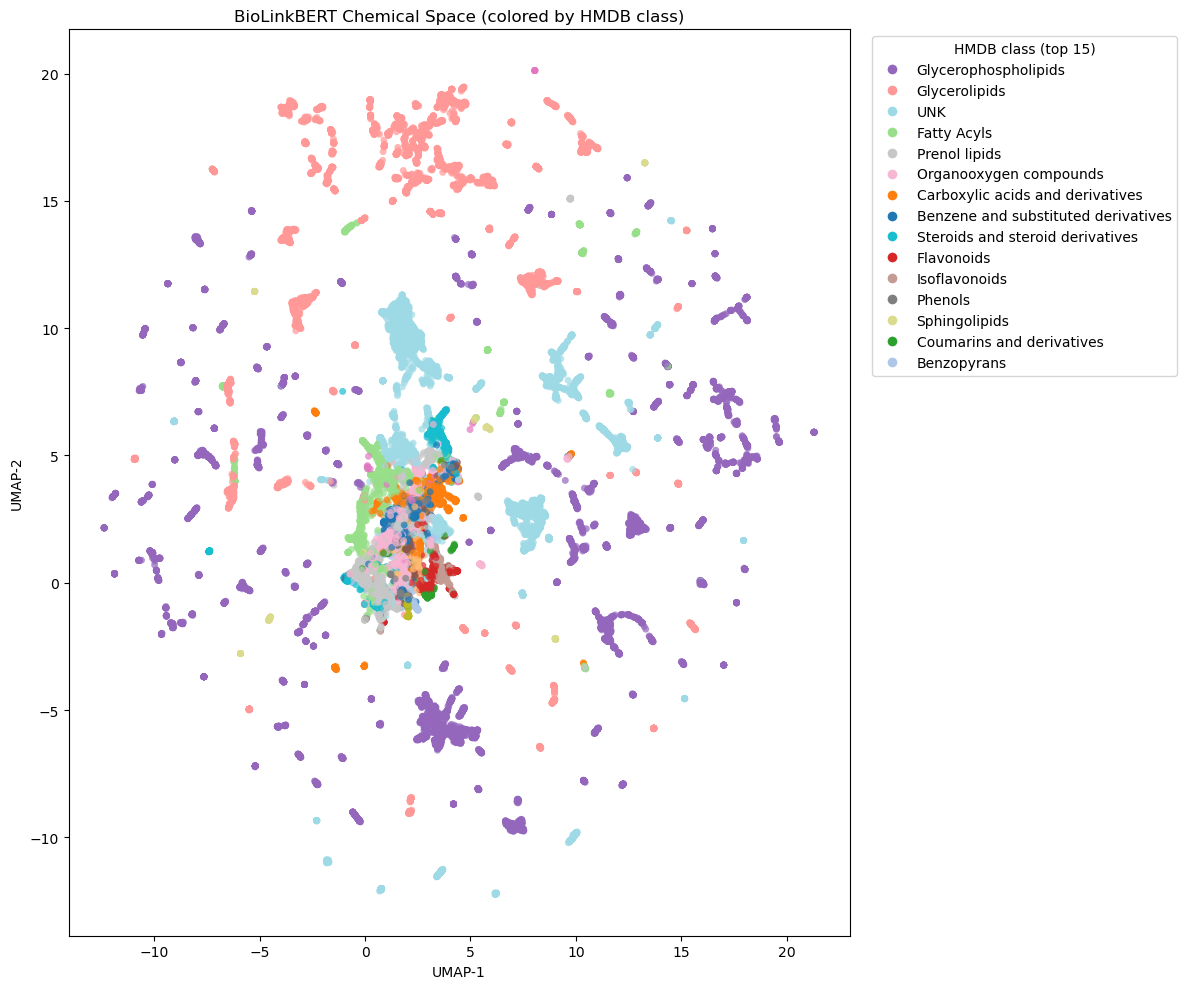

In [5]:
# ============================================================
# BioLinkBERT chemical space UMAP
# UPDATED:
#   - KB parquet is now molformer_pubchem_index_enriched_semantic.parquet
#   - embeddings are a normal .npy => load with np.load (not memmap)
#   - CID is string like "CID16724" => parse to int safely (optional)
#
#   - colors = HMDB class
#   - point size = (#PathBank pathways > 0) (same as your original logic)
# ============================================================

import re
import numpy as np
import pandas as pd
from pathlib import Path

from umap.umap_ import UMAP
import matplotlib.pyplot as plt

# ----------------------------
# PATHS
# ----------------------------
EMB_NPY = Path(r"metaspace_images_dump/cand_molecule_biolinkbert_embeddings.npy")
IDX_PQ  = Path(r"metaspace_images_dump/cand_molecule_biolinkbert_index.parquet")
KB_PQ   = Path(r"metaspace_images_dump/molformer_pubchem_index_enriched_semantic.parquet")

# ----------------------------
# Helpers
# ----------------------------
def extract_tax_field(tax: str, key: str):
    if not isinstance(tax, str) or not tax.strip():
        return None
    m = re.search(rf"(?:^|;\s*){re.escape(key)}:([^;]+)", tax)
    return m.group(1).strip() if m else None

def split_paths(s):
    if not isinstance(s, str) or not s.strip():
        return []
    return [p.strip() for p in re.split(r"\s*;\s*", s) if p.strip()]

CID_RE = re.compile(r"(\d+)")

def parse_cid(x):
    """Accepts 16724, '16724', 'CID16724', 'CID 16724', etc. -> int or None."""
    if x is None:
        return None
    if isinstance(x, float) and np.isnan(x):
        return None
    s = str(x).strip()
    if not s:
        return None
    m = CID_RE.search(s)
    if not m:
        return None
    try:
        return int(m.group(1))
    except Exception:
        return None

# ----------------------------
# Load embeddings (regular npy)
# ----------------------------
if not EMB_NPY.exists():
    raise FileNotFoundError(f"Embeddings not found: {EMB_NPY}")
E = np.load(EMB_NPY)
if E.dtype != np.float32:
    E = E.astype(np.float32, copy=False)
print("Embeddings:", E.shape, E.dtype)

# ----------------------------
# Load index + KB + align
# ----------------------------
if not IDX_PQ.exists():
    raise FileNotFoundError(f"Index not found: {IDX_PQ}")
if not KB_PQ.exists():
    raise FileNotFoundError(f"KB parquet not found: {KB_PQ}")

idx = pd.read_parquet(IDX_PQ)
kb  = pd.read_parquet(KB_PQ).copy()

# Ensure 'row' exists in KB; if not, assume row order matches embedding order
if "row" not in kb.columns:
    kb["row"] = np.arange(len(kb), dtype=int)

# Parse CID in KB (optional) and preserve raw
if "cid" in kb.columns:
    kb["cid_raw"] = kb["cid"].astype(str)
    kb["cid"] = kb["cid"].map(parse_cid).astype("Int64")
else:
    kb["cid_raw"] = None
    kb["cid"] = pd.Series([pd.NA] * len(kb), dtype="Int64")

# Merge on row; take cid from idx if you prefer (idx already has parsed cid + cid_raw)
df = (
    kb.merge(idx[["row", "cid_raw", "cid"]], on="row", how="inner", suffixes=("_kb", ""))
    .sort_values("row")
    .reset_index(drop=True)
)

# Sanity check
if len(df) != E.shape[0]:
    raise RuntimeError(f"Row mismatch: aligned df={len(df)} vs E={E.shape[0]}")

# ----------------------------
# Labels
# ----------------------------
df["hmdb_class"] = df.get("hmdb_taxonomy", "").astype(str).map(lambda s: extract_tax_field(s, "class"))
df["hmdb_class"] = df["hmdb_class"].fillna("UNK")

df["n_pathways"] = df.get("pathbank_pathway_names", "").astype(str).map(lambda s: len(split_paths(s)))

# Only show well-represented classes
min_n = 100
vc = df["hmdb_class"].value_counts()
keep = vc[vc >= min_n].index

mask = df["hmdb_class"].isin(keep)
print("Classes plotted:", len(keep), "of", df["hmdb_class"].nunique())

E_plot = E[mask.values]
df_plot = df.loc[mask].reset_index(drop=True)

# ----------------------------
# UMAP
# ----------------------------
um = UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=42,
)
U = um.fit_transform(E_plot)

# ----------------------------
# Plot
# ----------------------------
classes = sorted(df_plot["hmdb_class"].unique())

import matplotlib.cm as cm
cmap = cm.get_cmap("tab20", len(classes))
color_map = {c: cmap(i) for i, c in enumerate(classes)}

colors = [color_map[c] for c in df_plot["hmdb_class"]]
sizes = 5 + 20 * (df_plot["n_pathways"] > 0).astype(int)

plt.figure(figsize=(12, 10))
plt.scatter(U[:, 0], U[:, 1], c=colors, s=sizes, alpha=0.7, linewidths=0)

# Legend (top 15 largest classes)
top_classes = df_plot["hmdb_class"].value_counts().head(15).index
handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=c,
               markerfacecolor=color_map[c], markersize=8)
    for c in top_classes
]
plt.legend(handles=handles, title="HMDB class (top 15)", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.title("BioLinkBERT Chemical Space (colored by HMDB class)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()
